In [1]:

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

print(f"Dataset shape: X={X.shape}, y={y.shape}")

Dataset shape: X=(1000, 10), y=(1000,)


In [3]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(700, 10), y_train=(700,)
Testing set shape: X_test=(300, 10), y_test=(300,)


In [4]:
# Initialize and train a single Decision Tree Classifier
single_tree_model = DecisionTreeClassifier(random_state=42)
single_tree_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_single_tree = single_tree_model.predict(X_test)
accuracy_single_tree = accuracy_score(y_test, y_pred_single_tree)

print(f"Accuracy of a single Decision Tree Classifier: {accuracy_single_tree:.4f}")

Accuracy of a single Decision Tree Classifier: 0.9667


In [5]:
# Initialize and train a Bagging Classifier with Decision Trees
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                  n_estimators=50,
                                  random_state=42,
                                  n_jobs=-1)
bagging_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_bagging = bagging_model.predict(X_test)
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)

print(f"Accuracy of Bagging Classifier: {accuracy_bagging:.4f}")

Accuracy of Bagging Classifier: 0.9700


/tmp/ipykernel_9555/4128139220.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=performance_data, palette='viridis')


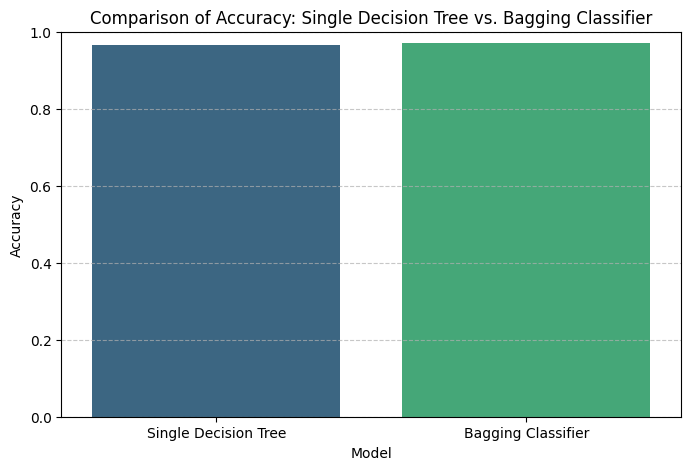


Summary of Performance:

Single Decision Tree Accuracy: 0.9667
Bagging Classifier Accuracy: 0.9700
Bagging Classifier performed better than the single Decision Tree.


In [6]:
# Create a DataFrame for easy plotting
performance_data = pd.DataFrame({
    'Model': ['Single Decision Tree', 'Bagging Classifier'],
    'Accuracy': [accuracy_single_tree, accuracy_bagging]
})

# Plot the comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=performance_data, palette='viridis')
plt.title('Comparison of Accuracy: Single Decision Tree vs. Bagging Classifier')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\nSummary of Performance:\n")
print(f"Single Decision Tree Accuracy: {accuracy_single_tree:.4f}")
print(f"Bagging Classifier Accuracy: {accuracy_bagging:.4f}")

if accuracy_bagging > accuracy_single_tree:
    print("Bagging Classifier performed better than the single Decision Tree.")
elif accuracy_bagging < accuracy_single_tree:
    print("Single Decision Tree performed better than the Bagging Classifier.")
else:
    print("Both models performed equally well.")